In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

# Running Sherlock on low-quality / low-cell-count data

This notebook runs Sherlock on a dataset where per-perturbation cell counts are too
low for a standard run. The tutorial below summarizes how the input data was
prepared and how the training hyperparameters were adjusted to compensate.

## 1. Creating metacells

- **Metacell size**: cells are aggregated in groups of **4** (`bootstrap_4`). This
  size was chosen empirically — it gave the most reasonable number of DEGs per
  perturbation without introducing too much noise.
- **Cells per perturbation/condition**: aim for **~30 cells per perturbation per
  condition** before aggregation, so each condition has a reasonable number of
  metacells to work with.
- **Perturbation selection**: only perturbations with **enough detectable DEGs**
  are kept — perturbations with too weak a signal are dropped, since the model
  can't learn a meaningful effect from noise.
- **Gene selection**: take the **top 10 DEGs per perturbation**, preferring genes
  that are **mostly unique to a single perturbation** (rather than DEGs shared
  across many perturbations). This keeps the gene space informative without
  diluting per-perturbation signal.

## 2. Parameter tuning for small data

- **More epochs**: with small/low-quality data, increase `num_epochs` — the model
  needs more iterations to converge on a weaker signal.
- **Don't overfit the classification head**: watch the auxiliary perturbation
  classification accuracy (`cls_head` / CE loss) during training — it can overfit
  quickly on small data.
- **Lower `ce_lambda` if accuracy rises too fast**: if classification accuracy
  climbs too quickly early in training, reduce `ce_lambda` so the auxiliary CE
  loss doesn't dominate/distort the latent space before the main reconstruction
  signal has a chance to shape it.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scanpy as sc
import datetime
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, spearmanr

import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
pert_type = 'crispri'  # 'crispri' or 'crisprko'

In [4]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 12, 'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize']  = 12
mpl.rcParams['lines.linewidth'] = 2

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RUNS      = 5
N_CLUSTERS  = 6   # number of clusters for reproducibility analysis
RESULTS_DIR = f'{paths.RESULTS_DIR}/reproducibility_meta_bootstrap_only_v1_noconditions_v2'
figure_dir  = RESULTS_DIR + '/figures'

os.makedirs(figure_dir,              exist_ok=True)
os.makedirs(RESULTS_DIR + '/matrices', exist_ok=True)

# SHERLOCK_KWARGS = dict(
#     batch_size     = 4096,
#     #num_workers    = 0,
#     num_epochs     = 1000,
#     use_conditions = True,
#     validate_every = 20,
#     l0_lambda      = 20,
#     #l1_lambda      = 0.5,
#     #lr             = 1e-3,
#     patience       = 500,
#     #rho_init       = False,
#     #ntc_lambda     = 1.0,
#     latent_dim     = 16,
#     rank           = 6,
#     #n_epochs_kl_warmup = 10,
#     n_epochs_l0_warmup = 200
# ) 

print(f'Device: {DEVICE}')
print(f'Results: {RESULTS_DIR}')
print(f'N_RUNS={N_RUNS}  N_CLUSTERS={N_CLUSTERS}')

Device: cuda
Results: results/reproducibility_meta_bootstrap_only_v1_noconditions_v2
N_RUNS=5  N_CLUSTERS=6


In [5]:
SHERLOCK_KWARGS = dict(
    batch_size     = 4096,
    #num_workers    = 0,
    num_epochs     = 2500,
    use_conditions = False,
    validate_every = 20,
    l0_lambda      = 35,
    #l1_lambda      = 0.5,
    #lr             = 1e-3,
    patience       = 500,
    #rho_init       = False,
    #ntc_lambda     = 1.0,
    latent_dim     = 16,
    rank           = 6,
    ce_lambda       = 1,
    n_epochs_kl_warmup = 20,
    n_epochs_l0_warmup = 500
) 

In [6]:
slk.configs.reset_config()
slk.configs.set_config('ntc_label', 'non-targeting')
slk.configs.show()

ntc_label       = non-targeting
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


## Data loading & preprocessing

In [7]:

adata_path = f'{paths.DATA_DIR}/gbm/filtered_gbm_{pert_type}_crop_top_bootstrap_4.h5ad'
adata = sc.read(adata_path)
print(adata)

AnnData object with n_obs × n_vars = 8640 × 570
    obs: 'gene_id', 'treatment', 'treatment_geneid', 'dose', 'n_cells_summed'
    var: 'features'


In [8]:


# Remap dose to treatment labels
mapping = {1.: '1to1', 0.5: '1to0.5', 0.25: '1to0.25', 0.: 'Untreated'}
adata.obs['treatment'] = adata.obs['dose'].replace(mapping)

print(f'After filtering: {adata.n_obs} cells, {adata.n_vars} genes')
print(f'Treatment labels: {sorted(adata.obs["treatment"].unique())}')

After filtering: 8640 cells, 570 genes
Treatment labels: ['1to0.25', '1to0.5', '1to1', 'Untreated']


In [9]:
adata = adata[adata.obs['treatment'] != 'Untreated']

In [10]:
data = adata.copy()
data.obs.dose = data.obs.dose.astype(str)

slk.pp.slk_prepare_data(
    data, pert_key='gene_id', ntc_label='NTC', inplace=True, force=True
)

p_key     = slk.configs.get_config('pert_key')
NTC       = slk.configs.get_config('ntc_label')
c_key     = slk.configs.get_config('treatment_key')

print(f'Cells: {data.n_obs}   Genes: {data.n_vars}')
print(f'Perturbations (non-NTC): {data.obs[p_key].nunique() - 1}')
print(f'Conditions: {sorted(data.obs[c_key].unique())}')

Cells: 6480   Genes: 570
Perturbations (non-NTC): 71
Conditions: ['untreated']


In [11]:
slk.pp.treat_effect(
    data, label_col='gene_id', control_label='NTC',
    method='perturbseq', inplace=True, key='treat_effect',
)
print('treat_effect computed.')

  0%|          | 0/71 [00:00<?, ?it/s]

100%|██████████| 71/71 [00:00<00:00, 2836.39it/s]

treat_effect computed.


## Part 1 — Reproducibility loop

Train `N_RUNS` independent models with the same hyperparameters but different random seeds.
Set `use_rerun = True` to skip runs that have already been saved.

In [12]:
use_rerun = True

for run in range(N_RUNS):
    out_path = f'{RESULTS_DIR}/matrices/run_{run}.npz'
    if os.path.exists(out_path) and use_rerun:
        print(f'Run {run+1}: already saved, skipping.')
        continue

    print(f"\n{'='*50}\nDeg-only run {run+1}/{N_RUNS}\n{'='*50}")
    out   = slk.tl.run_single(data, device=DEVICE, seed=run, **SHERLOCK_KWARGS, debug=True)
    model = out['model']

    slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    res = data.uns['results']

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    slk.tl.save_results(out, f'{paths.RESULTS_DIR}/models/{pert_type}_degonly_model_{timestamp}_{run}.pth')
    print(f'Saved model to ../data/{pert_type}_degonly_model_{timestamp}_{run}.pth')

    W          = np.asarray(res['W'],         dtype=float)
    rho_corr   = np.asarray(res['rho_corr'],  dtype=float)
    z_corr     = np.asarray(res['z_corr'],    dtype=float)
    rho_perts  = np.asarray(res['rho_perts'])
    cond_names = list(res['conditions'])
    cf_sizes   = [np.asarray(cf, dtype=float) for cf in res['counterfactual_effect_size']]
    cfs_mat    = np.asarray(res['condition_perturbation_interaction'], dtype=float)

    # ATE: predicted vs observed treatment effect correlation
    ate    = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'],
    )
    ate_r  = float(ate['corr'])
    pred_df = ate['predicted_df']

    # ev_sig qvals per condition
    for ci in range(len(cond_names)):
        slk.tl.ev_sig(data, cond_idx=ci)
        qvals = np.asarray(data.uns['results']['ev_results'][ci]['qvals'], dtype=float)
        np.save(f'{RESULTS_DIR}/matrices/run_{run}_evqvals_{ci}.npy', qvals)

    # Save matrices
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_W.npy',        W)
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy', rho_corr)
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_z_corr.npy',   z_corr)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt',  rho_perts,  fmt='%s')
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_conds.txt',  cond_names, fmt='%s')
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_cfs_mat.npy',  cfs_mat)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt',  [ate_r],    fmt='%.6f')
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_ate_pred.npy', pred_df.values)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_perts.txt', list(pred_df.index), fmt='%s')
    for ci, cf in enumerate(cf_sizes):
        np.save(f'{RESULTS_DIR}/matrices/run_{run}_cf_{ci}.npy', cf)
    np.savez(out_path)  # sentinel

    # Keep the best-ATE model
    best_r_path = f'{RESULTS_DIR}/matrices/best_ate_r.txt'
    current_best = float(np.loadtxt(best_r_path)) if os.path.exists(best_r_path) else -np.inf
    if ate_r > current_best:
        slk.tl.save_results(out, f'{RESULTS_DIR}/matrices/best_model.pth')
        np.savetxt(best_r_path, [ate_r], fmt='%.6f')
        np.savetxt(f'{RESULTS_DIR}/matrices/best_run.txt', [run], fmt='%d')
        print(f'  New best model: ATE r={ate_r:.4f}')

    print(f'  Saved run {run+1} (ATE r={ate_r:.4f})')

print('\nTraining complete.')

Run 1: already saved, skipping.
Run 2: already saved, skipping.
Run 3: already saved, skipping.
Run 4: already saved, skipping.
Run 5: already saved, skipping.

Training complete.


## Part 2 — Load saved matrices

Re-entry point: run from here if matrices already exist.

In [13]:
run_results = []
_ntc_labels = {'ntc', 'control', 'ctrl', 'non-targeting', 'dmso', 'vehicle'}

for run in range(N_RUNS):
    W          = np.load(f'{RESULTS_DIR}/matrices/run_{run}_W.npy')
    rho_corr   = np.load(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy')
    z_corr     = np.load(f'{RESULTS_DIR}/matrices/run_{run}_z_corr.npy')
    rho_perts  = np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt', dtype=str, ndmin=1)
    # Filter NTC from saved perts
    rho_perts  = np.array([p for p in rho_perts if p.lower() not in _ntc_labels])
    cond_names = list(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_conds.txt', dtype=str, ndmin=1))
    cfs_mat    = np.load(f'{RESULTS_DIR}/matrices/run_{run}_cfs_mat.npy')
    ate_r      = float(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt'))
    ate_pred   = np.load(f'{RESULTS_DIR}/matrices/run_{run}_ate_pred.npy')
    ate_perts  = list(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_perts.txt', dtype=str, ndmin=1))
    n_conds    = len(cond_names)
    cf_sizes   = [np.load(f'{RESULTS_DIR}/matrices/run_{run}_cf_{ci}.npy') for ci in range(n_conds)]
    ev_qvals   = [np.load(f'{RESULTS_DIR}/matrices/run_{run}_evqvals_{ci}.npy') for ci in range(n_conds)]

    run_results.append(dict(
        run=run, W=W, rho_corr=rho_corr, z_corr=z_corr,
        rho_perts=rho_perts, cond_names=cond_names,
        cfs_mat=cfs_mat, ate_r=ate_r, ate_pred=ate_pred,
        ate_perts=ate_perts, cf_sizes=cf_sizes, ev_qvals=ev_qvals,
    ))
    print(f'Run {run+1}: ATE r={ate_r:.4f}  W {W.shape}  perts {len(rho_perts)}')

all_perts   = sorted(run_results[0]['rho_perts'].tolist())
cond_names  = run_results[0]['cond_names']
all_ate_r   = [r['ate_r'] for r in run_results]
best_run_id = int(np.argmax(all_ate_r))

print(f'\nATE r per run: {[f"{r:.4f}" for r in all_ate_r]}')
print(f'Mean +/- Std: {np.mean(all_ate_r):.4f} +/- {np.std(all_ate_r):.4f}')
print(f'Best run: {best_run_id+1} (ATE r={all_ate_r[best_run_id]:.4f})')
print(f'Conditions: {cond_names}')

Run 1: ATE r=0.3220  W (71, 16)  perts 71
Run 2: ATE r=0.3309  W (71, 16)  perts 71
Run 3: ATE r=0.3009  W (71, 16)  perts 71
Run 4: ATE r=0.3088  W (71, 16)  perts 71
Run 5: ATE r=0.2837  W (71, 16)  perts 71

ATE r per run: ['0.3220', '0.3309', '0.3009', '0.3088', '0.2837']
Mean +/- Std: 0.3093 +/- 0.0165
Best run: 2 (ATE r=0.3309)
Conditions: ['untreated']


## Helper functions

In [14]:
def align_groups_to_reference(ref_ng, tgt_ng):
    """Hungarian-match tgt group labels to ref group labels by shared membership."""
    common = set(ref_ng.index) & set(tgt_ng.index)
    if not common:
        return {}
    ref_labels = sorted(ref_ng['group'].unique())
    tgt_labels = sorted(tgt_ng['group'].unique())
    C = np.zeros((len(ref_labels), len(tgt_labels)), dtype=int)
    for gene in common:
        ri = ref_labels.index(ref_ng.loc[gene, 'group'])
        ti = tgt_labels.index(tgt_ng.loc[gene, 'group'])
        C[ri, ti] += 1
    row_ind, col_ind = linear_sum_assignment(C.max() - C)
    mapping = {tgt_labels[j]: ref_labels[i] for i, j in zip(row_ind, col_ind)}
    for tl in tgt_labels:
        if tl not in mapping:
            genes_in_tl = [g for g in tgt_ng.index if tgt_ng.loc[g, 'group'] == tl and g in common]
            if genes_in_tl:
                vote = {}
                for g in genes_in_tl:
                    rg = ref_ng.loc[g, 'group']
                    vote[rg] = vote.get(rg, 0) + 1
                mapping[tl] = max(vote, key=vote.get)
    return mapping


def cluster_all_runs(run_results, n_clusters, all_perts):
    clustered = []
    for rr in run_results:
        groups = slk.tl.cluster_rho(
            data, t=n_clusters, rho_corr=rr['z_corr'],
            criterion='maxclust', show=False,
        )
        named_groups = slk.tl.group2name(groups, list(rr['rho_perts']))
        clustered.append({**rr, 'groups': groups, 'named_groups': named_groups})
    return clustered


def compute_confidence(clustered_runs, all_perts):
    ref_ng     = clustered_runs[0]['named_groups']
    ref_groups = sorted(ref_ng['group'].unique())
    n_runs     = len(clustered_runs)

    aligned = {p: [] for p in all_perts}
    for rr in clustered_runs:
        mapping = ({g: g for g in ref_groups} if rr['run'] == 0
                   else align_groups_to_reference(ref_ng, rr['named_groups']))
        ng = rr['named_groups']
        for p in all_perts:
            if p in ng.index:
                aligned[p].append(mapping.get(ng.loc[p, 'group'], -1))
            else:
                aligned[p].append(-1)

    group_cols = [f'Group {g}' for g in ref_groups]
    rows = []
    for p in all_perts:
        asn  = aligned[p]
        row  = {f'Group {g}': asn.count(g) / n_runs for g in ref_groups}
        row['modal_group'] = f'Group {max(ref_groups, key=lambda g: asn.count(g))}'
        row['max_conf']    = max(asn.count(g) for g in ref_groups) / n_runs
        row['unassigned']  = asn.count(-1) / n_runs
        rows.append({'perturbation': p, **row})

    df = pd.DataFrame(rows).set_index('perturbation')
    return df.sort_values(['modal_group', 'max_conf'], ascending=[True, False]), group_cols


def jaccard(labels_i, labels_j):
    n      = len(labels_i)
    same_i = labels_i[:, None] == labels_i[None, :]
    same_j = labels_j[:, None] == labels_j[None, :]
    triu   = np.triu_indices(n, k=1)
    a, b   = same_i[triu], same_j[triu]
    union  = int((a | b).sum())
    return int((a & b).sum()) / union if union > 0 else np.nan


def compute_pairwise_similarity(run_results, clustered_runs, all_perts):
    """W co-activation, rho, and cluster Jaccard for every run pair."""
    n_runs = len(run_results)
    pairs  = list(combinations(range(n_runs), 2))
    w_corrs, rho_corrs, jac_raw, jac_aln = [], [], [], []

    for i, j in pairs:
        ri, rj = run_results[i], run_results[j]

        Ci   = ri['W'] @ ri['W'].T
        Cj   = rj['W'] @ rj['W'].T
        triu = np.triu_indices(Ci.shape[0], k=1)
        w_corrs.append(pearsonr(Ci[triu], Cj[triu])[0])

        fi, fj = ri['z_corr'][triu], rj['z_corr'][triu]
        valid  = np.isfinite(fi) & np.isfinite(fj)
        rho_corrs.append(pearsonr(fi[valid], fj[valid])[0])

        ci_r, cj_r = clustered_runs[i], clustered_runs[j]
        jac_raw.append(jaccard(ci_r['groups'].astype(object), cj_r['groups'].astype(object)))

        ng_i, ng_j = ci_r['named_groups'], cj_r['named_groups']
        common     = [p for p in all_perts if p in ng_i.index and p in ng_j.index]
        mapping_ij = align_groups_to_reference(ng_i, ng_j)
        mp_i = np.array([ng_i.loc[p, 'group'] for p in common], dtype=object)
        mp_j = np.array([mapping_ij.get(ng_j.loc[p, 'group'], -1) for p in common], dtype=object)
        valid_mask = mp_j != -1
        jac_aln.append(jaccard(mp_i[valid_mask], mp_j[valid_mask]))

    return pairs, w_corrs, rho_corrs, jac_raw, jac_aln

## Part 3 — W and rho reproducibility

For every run pair:
- **W co-activation Pearson r**: correlation of upper triangle of W @ W^T matrices
- **rho (z_corr) Pearson r**: correlation of perturbation correlation matrices

In [15]:
clustered_runs = cluster_all_runs(run_results, N_CLUSTERS, all_perts)
pairs, w_corrs, rho_corrs, jac_raw, jac_aln = compute_pairwise_similarity(
    run_results, clustered_runs, all_perts
)

print('Pairwise W co-activation Pearson r:')
print(f'  Mean +/- Std: {np.mean(w_corrs):.4f} +/- {np.std(w_corrs):.4f}')
print(f'  Min / Max : {np.min(w_corrs):.4f} / {np.max(w_corrs):.4f}')

print('\nPairwise rho (z_corr) Pearson r:')
valid_rho = [v for v in rho_corrs if np.isfinite(v)]
print(f'  Mean +/- Std: {np.mean(valid_rho):.4f} +/- {np.std(valid_rho):.4f}')
print(f'  Min / Max : {np.min(valid_rho):.4f} / {np.max(valid_rho):.4f}')

Pairwise W co-activation Pearson r:
  Mean +/- Std: 0.2139 +/- 0.0888
  Min / Max : 0.0931 / 0.3739

Pairwise rho (z_corr) Pearson r:
  Mean +/- Std: 0.5773 +/- 0.0352
  Min / Max : 0.5317 / 0.6424


## Part 4 — Clustering reproducibility (N_CLUSTERS = 6)

In [16]:
confidence_df, group_cols = compute_confidence(clustered_runs, all_perts)
P_n      = len(all_perts)
pert_idx = {p: i for i, p in enumerate(all_perts)}

# Co-membership matrix
comembership = np.zeros((P_n, P_n))
for rr in clustered_runs:
    ng           = rr['named_groups']
    perts_in_run = [p for p in all_perts if p in ng.index]
    for pi in perts_in_run:
        gi = ng.loc[pi, 'group']
        for pj in perts_in_run:
            if ng.loc[pj, 'group'] == gi:
                comembership[pert_idx[pi], pert_idx[pj]] += 1
comembership /= N_RUNS
np.fill_diagonal(comembership, 1.0)

print(f'Clustering with N_CLUSTERS={N_CLUSTERS}:')
print(f'  Mean max-confidence : {confidence_df["max_conf"].mean():.3f} +/- {confidence_df["max_conf"].std():.3f}')
print(f'  Stable (>=0.8)      : {(confidence_df["max_conf"] >= 0.8).sum()} / {len(confidence_df)}')
print(f'  Pairwise Jaccard (aligned) : {np.nanmean(jac_aln):.3f} +/- {np.nanstd(jac_aln):.3f}')
print()
print(confidence_df.round(2).to_string())

Clustering with N_CLUSTERS=6:
  Mean max-confidence : 0.552 +/- 0.171
  Stable (>=0.8)      : 14 / 71
  Pairwise Jaccard (aligned) : 0.173 +/- 0.026

              Group 1  Group 2  Group 3  Group 4  Group 5  Group 6 modal_group  max_conf  unassigned
perturbation                                                                                        
BRDT              0.6      0.0      0.2      0.2      0.0      0.0     Group 1       0.6         0.0
CDK12             0.6      0.2      0.0      0.2      0.0      0.0     Group 1       0.6         0.0
PRKACG            0.6      0.2      0.0      0.0      0.0      0.2     Group 1       0.6         0.0
CDK2              0.4      0.0      0.0      0.0      0.2      0.4     Group 1       0.4         0.0
CDK4              0.4      0.4      0.0      0.0      0.2      0.0     Group 1       0.4         0.0
FGFR2             0.4      0.2      0.4      0.0      0.0      0.0     Group 1       0.4         0.0
PRPF4B            0.4      0.2      0.0   

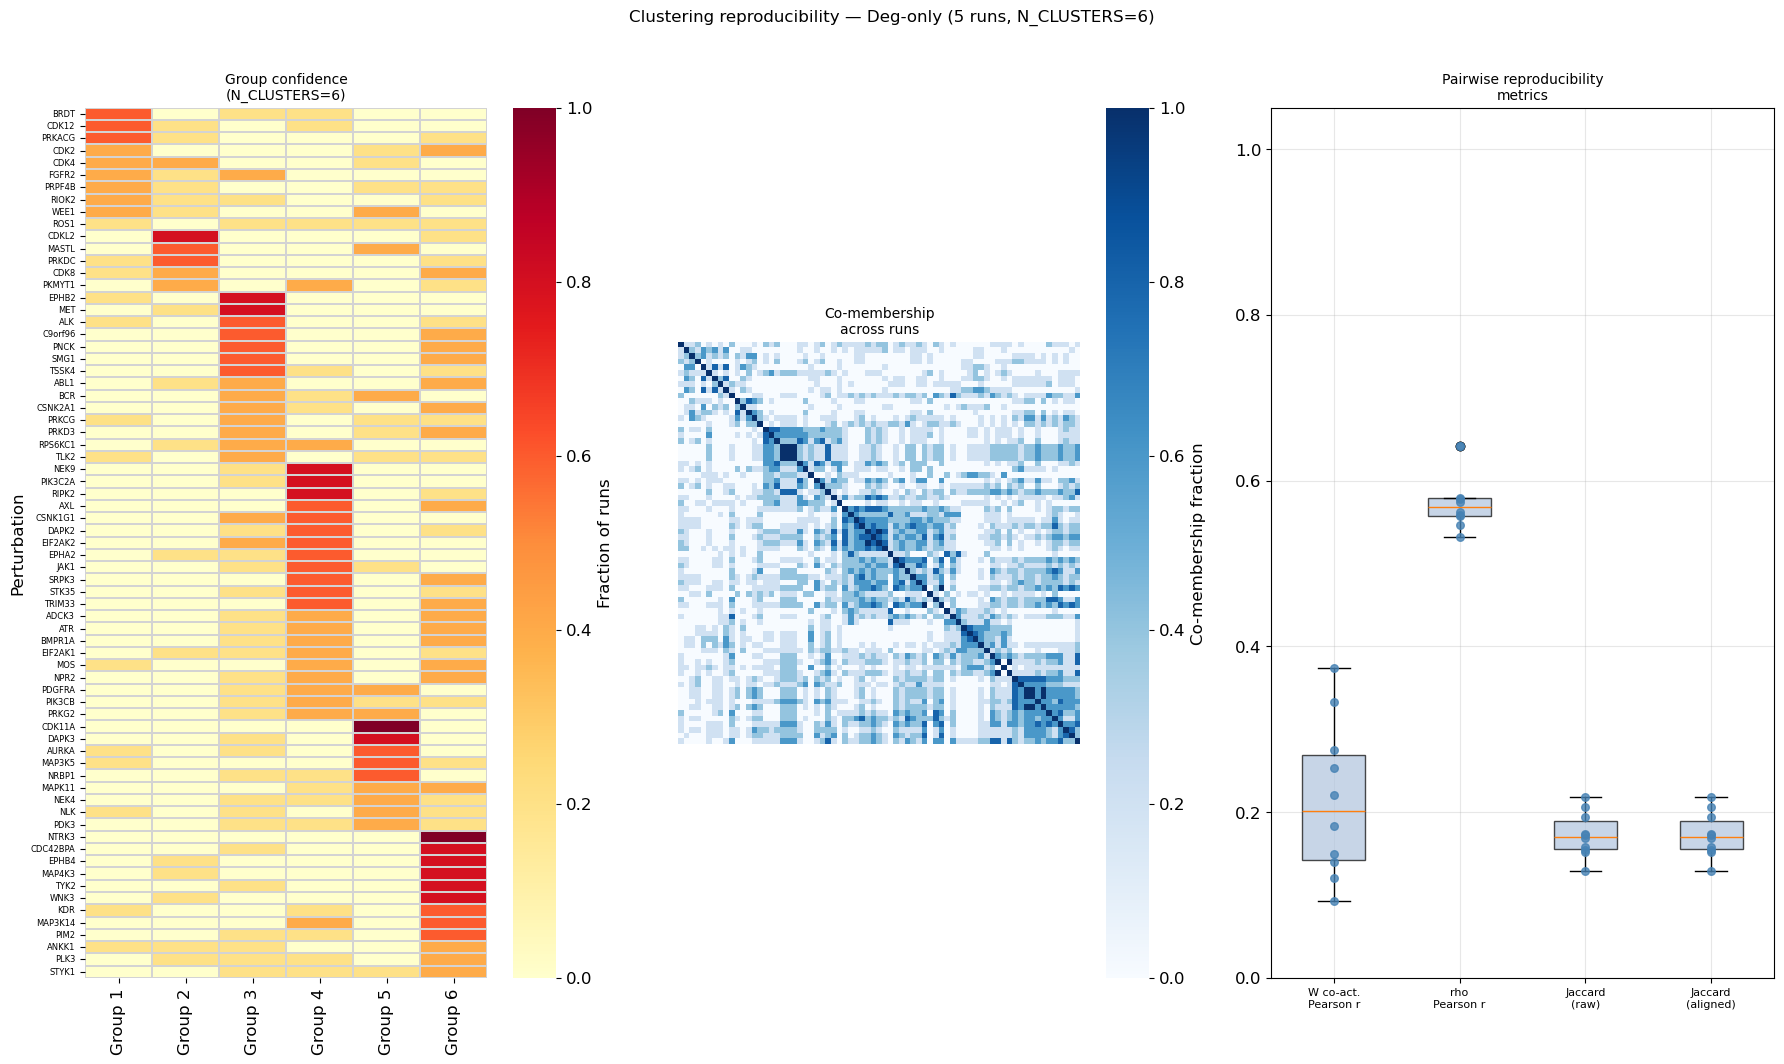

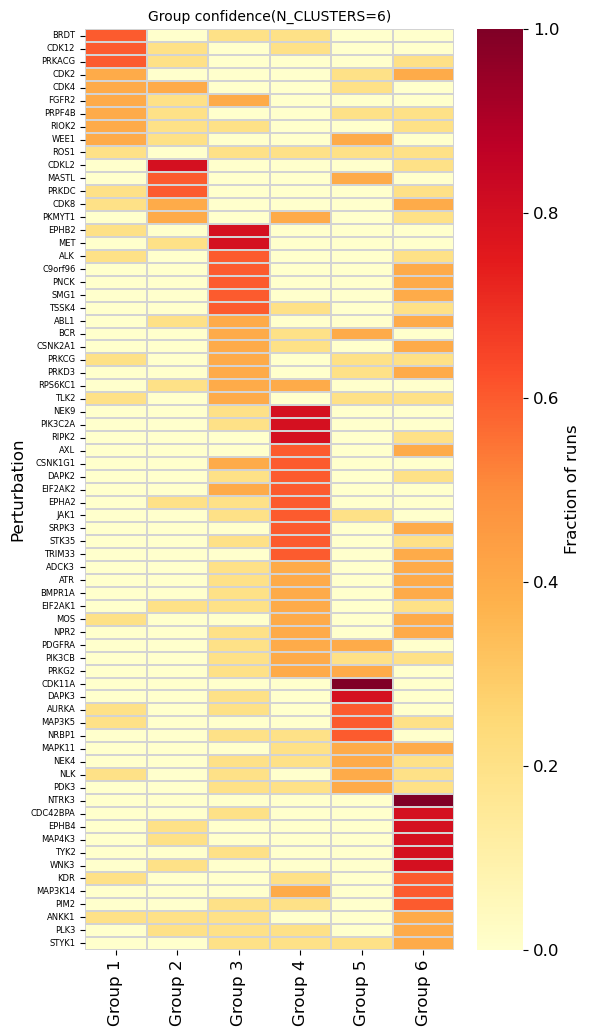

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(4, P_n * 0.12 + 2)))

# Confidence heatmap
sns.heatmap(
    confidence_df[group_cols], ax=axes[0],
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='lightgray',
    cbar_kws={'label': 'Fraction of runs'},
    annot=False, yticklabels=True,
)
axes[0].set_title(f'Group confidence\n(N_CLUSTERS={N_CLUSTERS})', fontsize=10)
axes[0].set_ylabel('Perturbation')
axes[0].tick_params(axis='y', labelsize=6)

# Co-membership heatmap
sort_order = confidence_df.index.tolist()
cm_plot    = pd.DataFrame(comembership, index=all_perts, columns=all_perts).loc[sort_order, sort_order]
sns.heatmap(
    cm_plot, ax=axes[1],
    cmap='Blues', vmin=0, vmax=1,
    xticklabels=False, yticklabels=False,
    cbar_kws={'label': 'Co-membership fraction'},
    square=True,
)
axes[1].set_title('Co-membership\nacross runs', fontsize=10)

# Reproducibility boxplot
for pos, (vals, title) in enumerate([
    (w_corrs,  'W co-act.\nPearson r'),
    (rho_corrs,'rho\nPearson r'),
    (jac_raw,  'Jaccard\n(raw)'),
    (jac_aln,  'Jaccard\n(aligned)'),
], 1):
    clean = [v for v in vals if np.isfinite(v)]
    axes[2].boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
    axes[2].scatter([pos]*len(clean), clean, color='steelblue', s=30, zorder=3, alpha=0.8)

axes[2].set_xticks(range(1, 5))
axes[2].set_xticklabels(['W co-act.\nPearson r', 'rho\nPearson r',
                          'Jaccard\n(raw)', 'Jaccard\n(aligned)'], fontsize=8)
axes[2].set_title('Pairwise reproducibility\nmetrics', fontsize=10)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'Clustering reproducibility — Deg-only ({N_RUNS} runs, N_CLUSTERS={N_CLUSTERS})',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/clustering_reproducibility_k{N_CLUSTERS}.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Save the confidence heatmap separately
fig_left, ax_left = plt.subplots(figsize=(6, max(4, P_n * 0.12 + 2)))
sns.heatmap(
    confidence_df[group_cols], ax=ax_left,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='lightgray',
    cbar_kws={'label': 'Fraction of runs'},
    annot=False, yticklabels=True,
)
ax_left.set_title(f'Group confidence(N_CLUSTERS={N_CLUSTERS})', fontsize=10)
ax_left.set_ylabel('Perturbation')
ax_left.tick_params(axis='y', labelsize=6)
plt.tight_layout()
for ext in ['png', 'svg', 'pdf']:
    plt.savefig(f'{RESULTS_DIR}/figures/crisri_clustering_confidence_heatmap_k{N_CLUSTERS}.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()
